In [1]:
from neuron import h
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from copy import deepcopy
import seaborn as sns

In [2]:
h.load_file("main.hoc")
h.load_file("ampa_nmda_ltp.hoc")

	1 
	1 
	1 
	1 
	0 
	1 
23 
	1 
	1 
After any change to cell geometry or nseg, be sure to invoke setpointers()
	1 
	1 
	1 
	0 
	0 
	0 
	0 
	0 
	0 
	1 
	1 
	1 
	1 
	0 
	0 
	0 
	0 
	0 
	0 
	42 
	34.521743 
	42 
	0.65135364 
Inserting synapse 1 
Randomly selected apical dendrite: 13 
Randomly selected location: 0.25125638 
Randomly determined distance to soma: 144.97643 
The synapse will receive input at 0 ms

Inserting synapse 2 
Randomly selected apical dendrite: 20 
Randomly selected location: 0.39552089 
Randomly determined distance to soma: 218.14662 
The synapse will receive input at 0 ms

Inserting synapse 3 
Randomly selected apical dendrite: 19 
Randomly selected location: 0.36252887 
Randomly determined distance to soma: 212.35181 
The synapse will receive input at 0 ms

Inserting synapse 4 
Randomly selected apical dendrite: 11 
Randomly selected location: 0.21324374 
Randomly determined distance to soma: 102.6 
The synapse will receive input at 0 ms

Inserting synapse 5 
Rando

1.0

unsynchronized poisson inputs (theta / gamma 10/50 Hz) - 1 minute

# CNS 2025

Aušra is suggesting to investigate the **synaptic plasticity neuromodulation by TI during theta oscillations at hippocampal CA3- CA1 synapses**.

Steps:

1. Stimulate the synapses to induce LTP and LTD to select model parameters.

    According to Dainauskas et al. (2023):
    
    >
    > Synapses were stimulated at 100 Hz for 1 s (LTP protocol) or at 1 Hz for 500 s (LTD protocol) as in the study by Pousinha et al. (2017).
    >

2. Analyse effect of TI.

theta burst

1 V/m (130 Hz)
0.4 V/m
0.1 V/m

parallel vs perpendicular

TI modulates the sensitivity of the microcircuits

Title: Subthreshold extracellular electric fields alter how neurons respond to naturally occurring synaptic inputs in Temporal Interference

(1) recreate figure 4 from the paper (but it is lying - 9 kHz is not any different from 1 kHz)
(2) 0.4 and 1 V/m selected from actual values from the human head
(3) parallel vs perpendicular electric fields - twice as much
(4) theta + sub-threshold AM signal (5 kHz envelope) -> the main point of the paper! (the title)

synaptic plasticity:
- theta (naturally occurring) + 5 Hz -- memory enhancement (what happens when it is turned off?)
- 130 Hz

TODO:
- lower frequency
- lower weight
- lower EF strength + ask whether the neuron should spike or whether the TI should be modulatory

- should external stimulation alone produce aps? or should be modulatory?

- usse variable dt (in python?)

- select the amplitude which is the largest but does not elicit APs neither before nor after the LTP induction
- use variable dt (try to set it in python)
- what happens to spike timing? spike frequency? weight distributions after the LTP in various stimulation conditions?
- try to clean up code: add documentation, rewrite synapse insertion to python

## LTP protocol

In [3]:
def set_stimulus(delay = 100, duration = 900, frequency1 = 1000, frequency2 = 1005, amplitude = 100, phase = 0):
    h.setstim(delay, duration, frequency1, frequency2, amplitude, phase)

In [4]:
class Simulation:
    def __init__(self,
                 frequency1,
                 frequency2,
                 amplitude,
                 delay = 0,
                 duration = 3000,
                 n_synapses = 10,
                 ltp_start = 1000,
                 ltp_end = 2000
         ):
        self.frequency1 = frequency1
        self.frequency2 = frequency2
        self.amplitude = amplitude
        self.delay = delay
        self.duration = duration
        self.n_synapses = n_synapses
        self.ltp_start = ltp_start
        self.ltp_end = ltp_end
        
        self.is_ti = frequency1 != frequency2
        
        self.result = None
        self.synapse_weights = None

    def run_ltp_simulation(self):
        set_stimulus(
            delay = self.delay,
            duration = self.duration - self.delay,
            frequency1 = self.frequency1,
            frequency2 = self.frequency2,
            amplitude = self.amplitude,
            phase = 0 if not self.is_ti else 10
        )
    
        h.tstop = self.duration
    
        synapse_weights = []
        for i in range(self.n_synapses):
            syn_weight = h.Vector().record(h.connections_ampa[i]._ref_weight[1])
            synapse_weights.append(syn_weight)
    
        soma = h.Vector().record(h.soma[0](0.5)._ref_v)
        t = h.Vector().record(h._ref_t)
    
        h.run()
    
        self.result = pd.DataFrame({
            "Time": t,
            "Soma": soma,
            "Frequency1": self.frequency1,
            "Frequency2": self.frequency2,
            "Amplitude": self.amplitude
        })
    
        result_syn = []
        for syn in synapse_weights:
            result_syn.append(deepcopy(np.array(syn)))
    
        self.synapse_weights = np.vstack(result_syn)
    
    def plot_result(self):
        fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 3.5))
        
        axs[0].plot(self.result.Time, self.result.Soma, label = "Soma", lw = 0.5, color = "black")
        axs[0].set_ylabel(r"$V_m$, mV")
        axs[0].set_xlabel("Time, ms")
        axs[0].set_ylim(-110, 70)
        axs[0].axvspan(
            self.ltp_start, self.ltp_end, alpha = 0.1,
            color = "orange",
            label = "LTP induction",
        )
        
        if self.is_ti:
            axs[0].set_title(rf"TI $\Delta f = {abs(int(self.frequency1 - self.frequency2))}$ Hz" + "\n" + rf"$E_0 = {self.amplitude}$ V/m")
        else:
            axs[0].set_title(rf"$f = {int(self.frequency1)}$ Hz" + "\n" + rf"$E_0 = {self.amplitude}$ V/m")
        
        for synapse in self.synapse_weights:
            axs[1].plot(self.result.Time, synapse / 0.00009, linewidth = 0.5)
        
        if self.is_ti:
            axs[1].set_title(rf"TI $\Delta f = {abs(int(self.frequency1 - self.frequency2))}$ Hz" + "\n" + rf"$E_0 = {self.amplitude}$ V/m")
        else:
            axs[1].set_title(rf"$f = {int(self.frequency1)}$ Hz" + "\n" + rf"$E_0 = {self.amplitude}$ V/m")
        
        axs[1].set_ylim(-0.1, 1.1)
        
        axs[1].axvspan(
            self.ltp_start, self.ltp_end, alpha = 0.1,
            color = "orange",
            label = "LTP induction",
        )
        
        axs[1].set_xlabel("Time, ms")
        axs[1].set_ylabel("Synaptic strength")
        
        plt.tight_layout()

In [ ]:
simulation_nostim = Simulation(
    frequency1 = 0,
    frequency2 = 0,
    amplitude = 0,
    duration = 5
)

simulation_nostim.run_ltp_simulation()
simulation_nostim.plot_result()

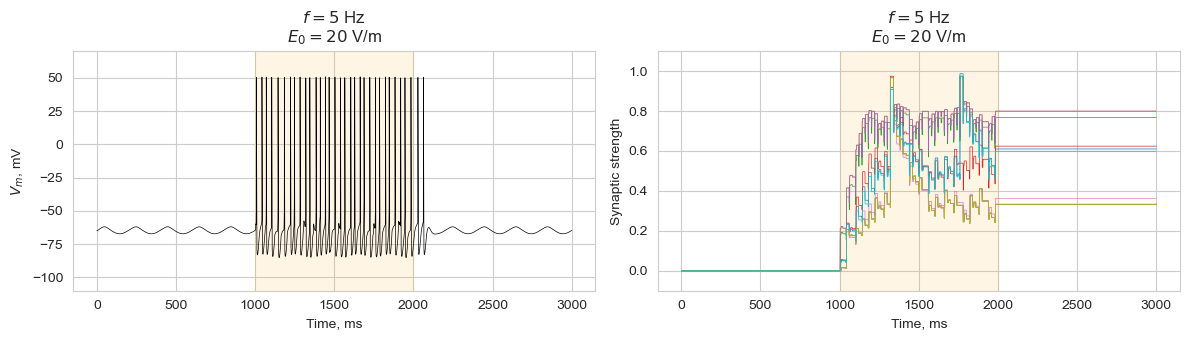

In [8]:
simulation_5hz = Simulation(
    frequency1 = 5,
    frequency2 = 5,
    amplitude = 20
)

simulation_5hz.run_ltp_simulation()
simulation_5hz.plot_result()

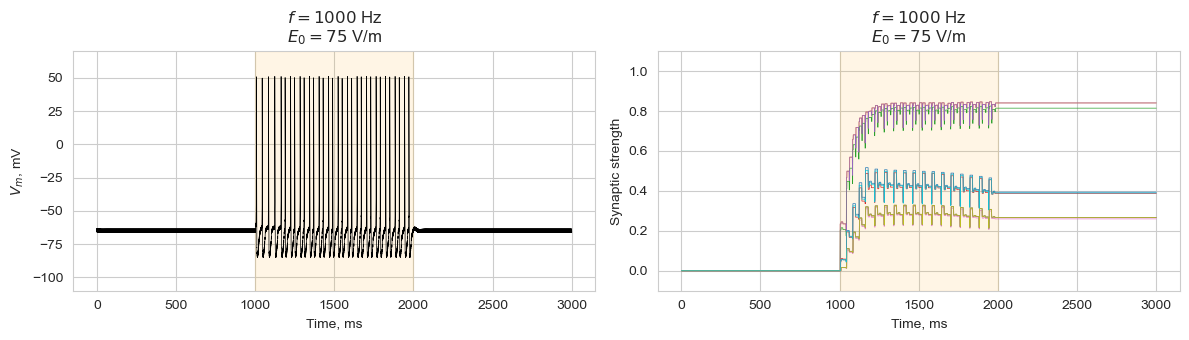

In [6]:
simulation_100hz = Simulation(
    frequency1 = 1000,
    frequency2 = 1000,
    amplitude = 75
)

simulation_100hz.run_ltp_simulation()
simulation_100hz.plot_result()

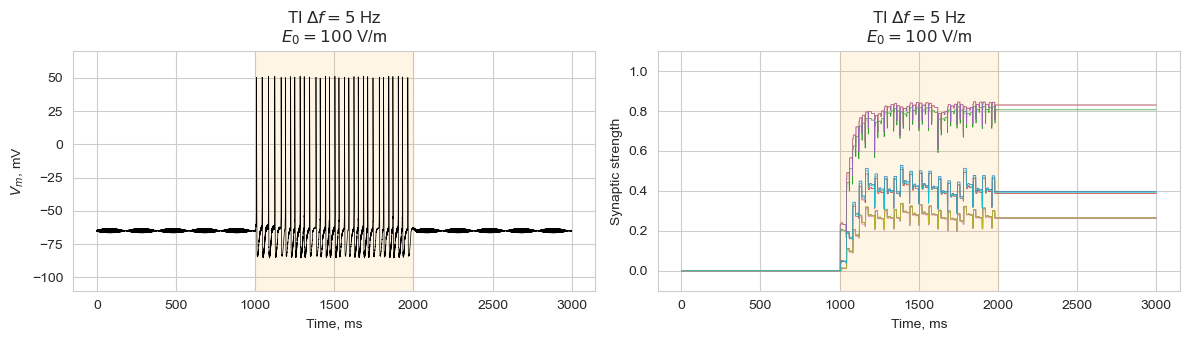

In [25]:
# How can I be sure that the electric field at the neuron is 1 V/m?

simulation_ti_5hz = Simulation(
    frequency1 = 1000,
    frequency2 = 1005,
    amplitude = 100
)
 
simulation_ti_5hz.run_ltp_simulation()
simulation_ti_5hz.plot_result()

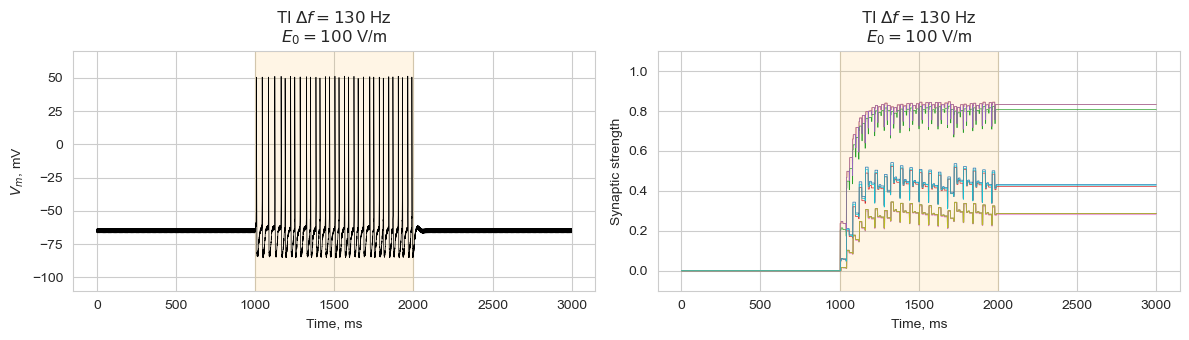

In [26]:
simulation_ti_100hz = Simulation(
    frequency1 = 1000,
    frequency2 = 1130,
    amplitude = 100
)

simulation_ti_100hz.run_ltp_simulation()
simulation_ti_100hz.plot_result()

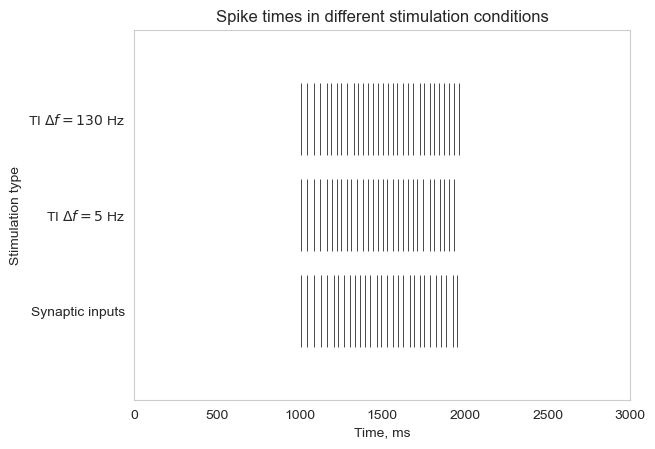

In [32]:
ap_threshold = -30

for i, sim_data in enumerate([ simulation_nostim.result, simulation_ti_5hz.result, simulation_ti_100hz.result ]):
    above_threshold = np.where(sim_data.Soma > ap_threshold)[0]
    ap_time = sim_data.Time[ above_threshold[ np.where(np.diff(above_threshold) > 1)[0] ] ]

    plt.eventplot(ap_time, lineoffsets = i + 1, linewidths = 0.5, linelengths = 0.75, colors = "black")

plt.yticks(
    np.arange(1, 4, 1),
    [
        "Synaptic inputs",
        r"TI $\Delta f = 5$ Hz",
        r"TI $\Delta f = 130$ Hz"
    ]
)
plt.xlim(0, 3000)
plt.ylabel("Stimulation type")
plt.xlabel("Time, ms")
plt.title("Spike times in different stimulation conditions")
plt.grid(False)
plt.show()

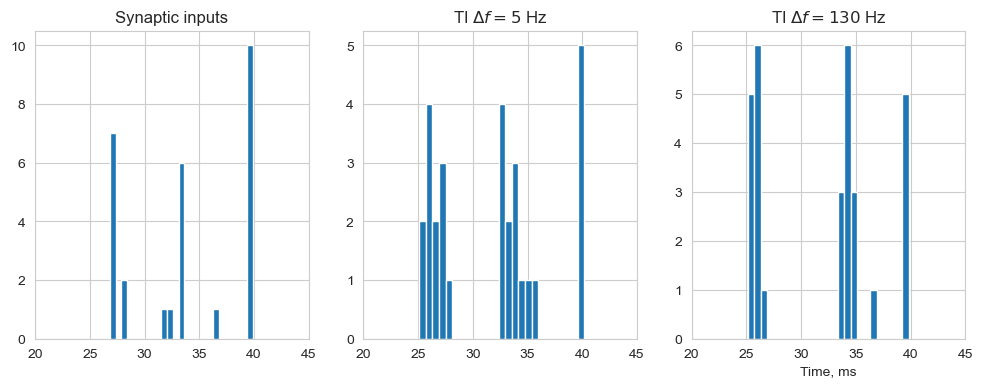

In [30]:
ap_threshold = -30

labels = [
    "Synaptic inputs",
    r"TI $\Delta f = 5$ Hz",
    r"TI $\Delta f = 130$ Hz"
]

fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 4))

for i, sim_data in enumerate([ simulation_nostim.result, simulation_ti_5hz.result, simulation_ti_100hz.result ]):
    above_threshold = np.where(sim_data.Soma > ap_threshold)[0]
    ap_time = sim_data.Time[ above_threshold[ np.where(np.diff(above_threshold) > 1)[0] ] ]
    isi = np.diff(ap_time)

    axs[i].hist(isi, bins = 25)
    axs[i].set_title(labels[i])
    axs[i].set_xlim(20, 45)
    # sns.kdeplot(isi, fill = False, ax = axs[i])

plt.xlabel("Time, ms")
plt.show()

TODO:
- excitatory post synaptic potential (EPSP) before and after stimulation
- should the start timing be different in different synapses?
- check: does the current flow through AMPA/NMDA channels during the stimulation?
- check: make sure the colors correspond to the same synapse
- why are some synapses potentiated fully and others not? does it depend on their location?
- how is the current synapse weight controlled? should it be set to a different value initially?

+ **run the simulation multiple times with randomized synapse locations**
+ determine minimum field strength that elicits APs
+ clean up code
+ run some stimulation before LTP onset

<pointer to hoc scalar 4.35576e-150>